# OCT Binary Classification — MobileNetV2 Method 2: Fine-Tuning

**Approach:** Phase 1: Frozen MobileNetV2 base, train classifier.
Phase 2: Unfreeze From layer 100 onwards, train with lower learning rate.
No data augmentation. Pickle checkpointing for Kaggle session recovery.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-17 02:24:08.246310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773714248.454844      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773714248.514286      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773714248.989107      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773714248.989144      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773714248.989146      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Data Loading

In [2]:
# Dataset paths
train_dir = '/kaggle/input/datasets/mohamedaminedrif/oct-binary/train'
val_dir = '/kaggle/input/datasets/mohamedaminedrif/oct-binary/val'
test_dir = '/kaggle/input/datasets/mohamedaminedrif/oct-binary/test'

for name, path in [('Train', train_dir), ('Validation', val_dir), ('Test', test_dir)]:
    if os.path.exists(path):
        print(f'\n{name} set:')
        for cls in sorted(os.listdir(path)):
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                print(f'  {cls}: {len(os.listdir(cls_path))} images')


Train set:
  DISEASE: 38842 images
  NORMAL: 21052 images

Validation set:
  DISEASE: 9711 images
  NORMAL: 5263 images

Test set:
  DISEASE: 484 images
  NORMAL: 242 images


## Data Generators (No Augmentation)

In [ ]:
# Data generators — rescaling ONLY, no augmentation
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True)
val_gen = datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)
test_gen = datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False)

print(f'Class mapping: {train_gen.class_indices}')
print(f'Training: {train_gen.samples} | Validation: {val_gen.samples} | Test: {test_gen.samples}')

Found 59894 images belonging to 2 classes.
Found 14974 images belonging to 2 classes.
Found 726 images belonging to 2 classes.
Class mapping: {'DISEASE': 0, 'NORMAL': 1}
Training: 59894 | Validation: 14974 | Test: 726


## Build MobileNetV2 Model (Frozen Base)

In [ ]:
# Build model with frozen base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1773714340.452175      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773714340.457836      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,297 (9.89 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Phase 1: Feature Extraction (Frozen Base)

In [11]:
# Training with pickle checkpointing
EPOCHS = 15
CKPT = '/kaggle/working/mobilenetv2_m2_p1_ckpt.pkl'
WGTS = '/kaggle/working/mobilenetv2_m2_p1_weights.weights.h5'

hist = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
start = 0

if os.path.exists(CKPT):
    with open(CKPT, 'rb') as f:
        ckpt = pickle.load(f)
    model.load_weights(WGTS)
    start = ckpt['epoch']
    hist = ckpt['history']
    print(f'Resuming from epoch {start}')

for epoch in range(start, EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    h = model.fit(train_gen, epochs=epoch+1, initial_epoch=epoch, validation_data=val_gen)
    for k in hist:
        hist[k].extend(h.history[k])
    model.save_weights(WGTS)
    with open(CKPT, 'wb') as f:
        pickle.dump({'epoch': epoch+1, 'history': hist}, f)

print(f'\nBest Val Accuracy: {max(hist["val_accuracy"])*100:.2f}%')

Resuming from epoch 15

Best Val Accuracy: 97.13%


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 122 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Phase 2: Fine-Tuning (From layer 100 onwards)

In [12]:
# Phase 2: Fine-Tuning — unfreeze top layers
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False
print(f'Trainable: {sum(1 for l in base_model.layers if l.trainable)} | Frozen: {sum(1 for l in base_model.layers if not l.trainable)}')

model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

P2_EPOCHS = 15
P2_CKPT = '/kaggle/working/mobilenetv2_m2_p2_ckpt.pkl'
P2_WGTS = '/kaggle/working/mobilenetv2_m2_p2_weights.weights.h5'

p2_hist = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
p2_start = 0

if os.path.exists(P2_CKPT):
    with open(P2_CKPT, 'rb') as f:
        ckpt = pickle.load(f)
    model.load_weights(P2_WGTS)
    p2_start = ckpt['epoch']
    p2_hist = ckpt['history']
    print(f'Resuming Phase 2 from epoch {p2_start}')

print('PHASE 2: Fine-Tuning')
print('=' * 50)

for epoch in range(p2_start, P2_EPOCHS):
    print(f'\nEpoch {epoch+1}/{P2_EPOCHS}')
    h = model.fit(train_gen, epochs=epoch+1, initial_epoch=epoch, validation_data=val_gen)
    for k in p2_hist:
        p2_hist[k].extend(h.history[k])
    model.save_weights(P2_WGTS)
    with open(P2_CKPT, 'wb') as f:
        pickle.dump({'epoch': epoch+1, 'history': p2_hist}, f)

print(f'\nBest Phase 2 Val Accuracy: {max(p2_hist["val_accuracy"])*100:.2f}%')

Trainable: 54 | Frozen: 100
Resuming Phase 2 from epoch 15
PHASE 2: Fine-Tuning

Best Phase 2 Val Accuracy: 98.28%


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 122 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Training Curves (Both Phases)

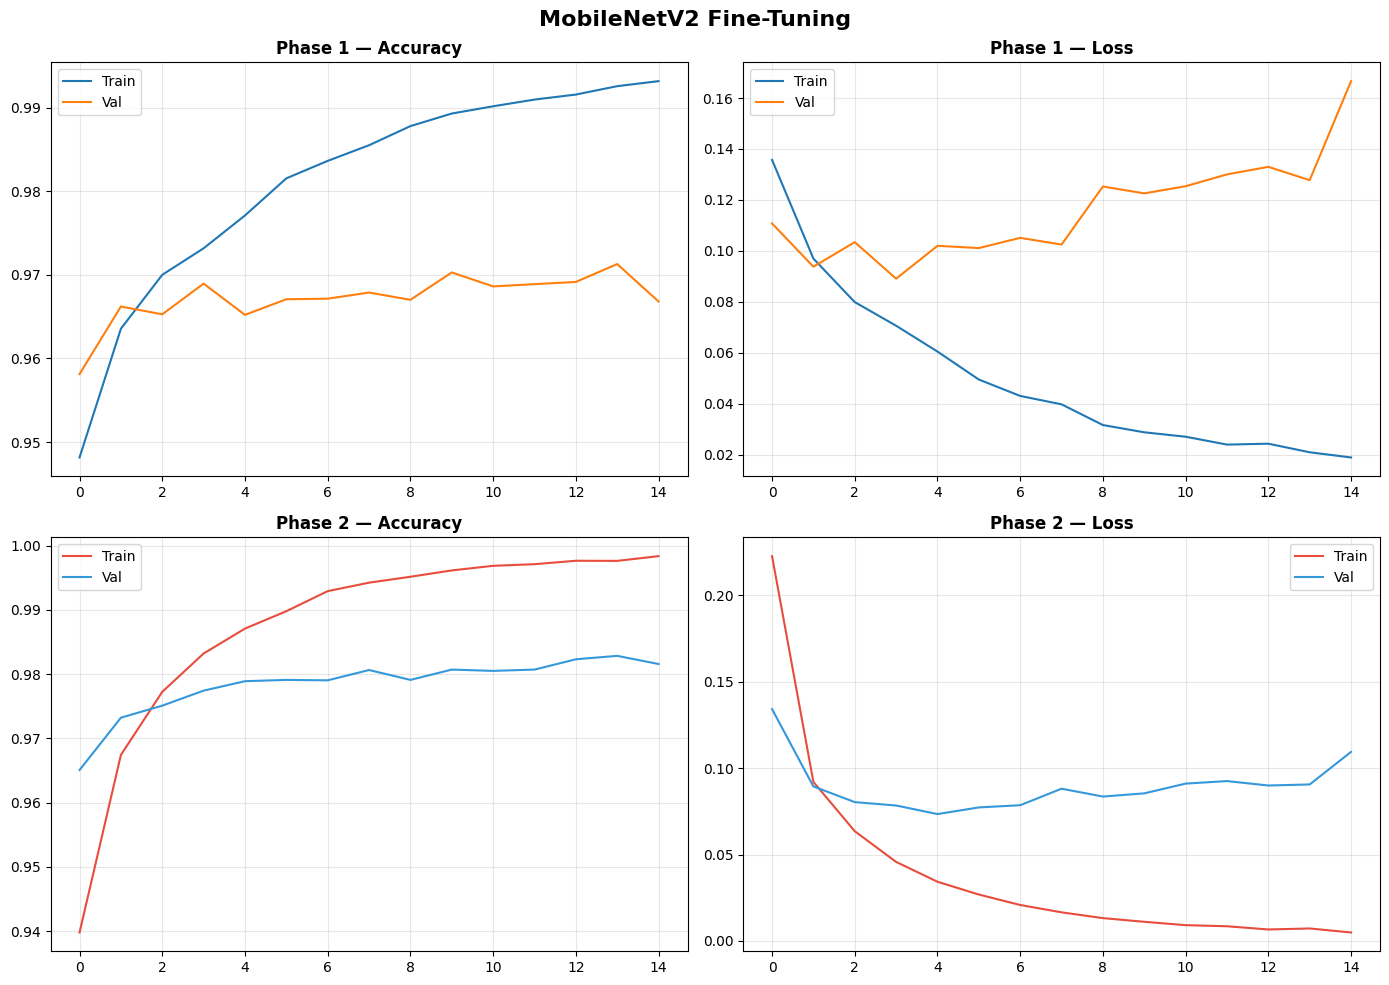

In [13]:
# Plot training curves — both phases
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(hist['accuracy'], label='Train'); axes[0,0].plot(hist['val_accuracy'], label='Val')
axes[0,0].set_title('Phase 1 — Accuracy', fontweight='bold'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(hist['loss'], label='Train'); axes[0,1].plot(hist['val_loss'], label='Val')
axes[0,1].set_title('Phase 1 — Loss', fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(p2_hist['accuracy'], label='Train', color='#e74c3c'); axes[1,0].plot(p2_hist['val_accuracy'], label='Val', color='#3498db')
axes[1,0].set_title('Phase 2 — Accuracy', fontweight='bold'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(p2_hist['loss'], label='Train', color='#e74c3c'); axes[1,1].plot(p2_hist['val_loss'], label='Val', color='#3498db')
axes[1,1].set_title('Phase 2 — Loss', fontweight='bold'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 Fine-Tuning', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## Evaluation

23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 306ms/step - accuracy: 0.9980 - loss: 0.0139

Test Accuracy: 99.72%
Test Loss: 0.0179
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 293ms/step


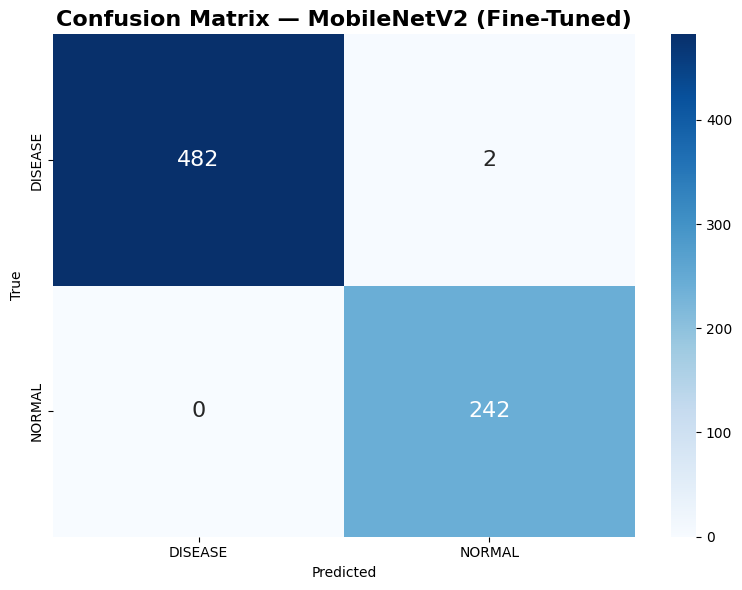

              precision    recall  f1-score   support

     DISEASE       1.00      1.00      1.00       484
      NORMAL       0.99      1.00      1.00       242

    accuracy                           1.00       726
   macro avg       1.00      1.00      1.00       726
weighted avg       1.00      1.00      1.00       726



In [14]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

# Confusion Matrix
test_gen.reset()
y_pred = (model.predict(test_gen) > 0.5).astype(int).flatten()
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={'size': 16})
plt.title('Confusion Matrix — MobileNetV2 (Fine-Tuned)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## Prediction Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


/tmp/ipykernel_55/1367170625.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(predictions[i] > 0.5)]


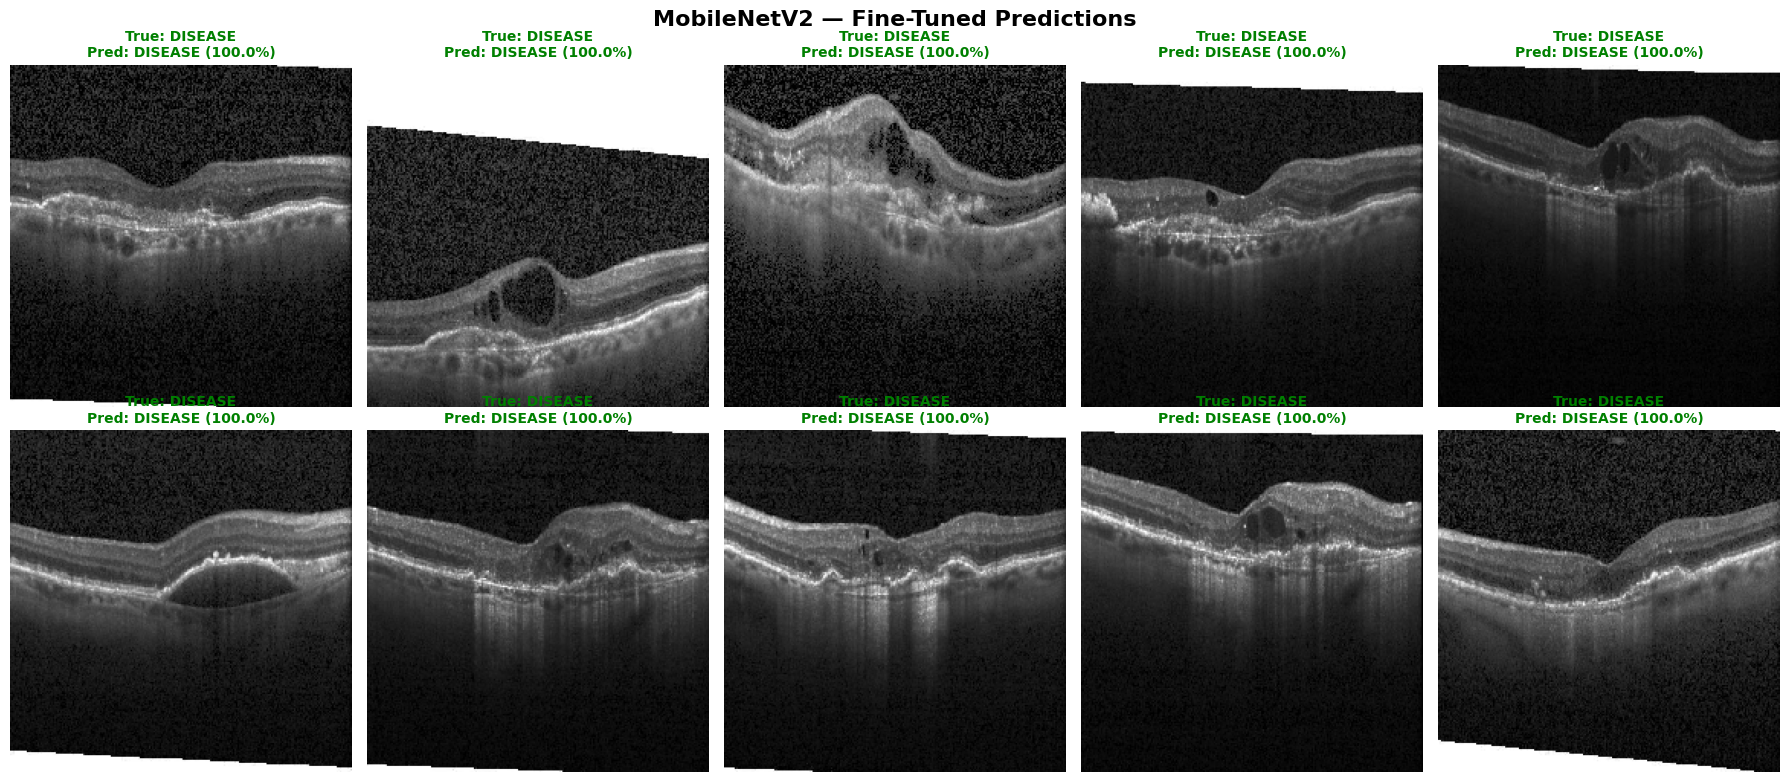

In [15]:
# Visualize predictions
test_gen.reset()
images, labels = next(test_gen)
predictions = model.predict(images)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    true_label = class_names[int(labels[i])]
    pred_label = class_names[int(predictions[i] > 0.5)]
    confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1%})', fontsize=10, color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('MobileNetV2 — Fine-Tuned Predictions', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## Save Model

In [16]:
model.save('mobilenetv2_method2_finetuned.keras')
print('Model saved as mobilenetv2_method2_finetuned.keras')

Model saved as mobilenetv2_method2_finetuned.keras
